# Stage Two
### Predicting Drug Sensitivity in Cancer (GDSC)

Using the same dataset as last week, build a machine learning models to predict the sensitivity of cancer cell lines to treatments using the ln(IC50) column.

There are two possible ways to approach this task. Either approach it as a classification task or regression task. If you are approaching it as a regression task, simply use the column LN_IC50 column.

If you are approaching it as a classification task i.e. to predict resistant and sensitive readings, we will perform a quantile-based split. Basically, anything below 25th percentile is sensitive and anything above 75% is resistant. Everything in between is discarded. You can adjust the thresholds if you like. See code below

lower = df["ln_IC50"].quantile(0.25) #0.25 can be adjust to any number between 0 and 1
upper = df["ln_IC50"].quantile(0.75) #0.75 can be adjust to any number between 0 and 1
Modeling: We suggest you try either random forest or xgboosting. They both have regression and classification methods.

Feature Importance and Evaluation: These are key components of your report and our grading. Justify everything like a biologist, don’t just look for numbers that pass a threshold.

In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [212]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Load Data

In [213]:
gdsc = pd.read_excel('./data/GDSC.xlsx')

In [214]:

gdsc.shape

(162103, 19)

In [215]:
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [216]:
gdsc.isnull().sum()

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

In [217]:
gdsc['LN_IC50'].describe()

count    162103.000000
mean          2.822644
std           2.836231
min          -8.642551
25%           1.476170
50%           3.271447
75%           4.767629
max          13.820189
Name: LN_IC50, dtype: float64

In [218]:
print(f"Range: {gdsc['LN_IC50'].min():.2f} to {gdsc['LN_IC50'].max():.2f}")

Range: -8.64 to 13.82


#### Distribution plot

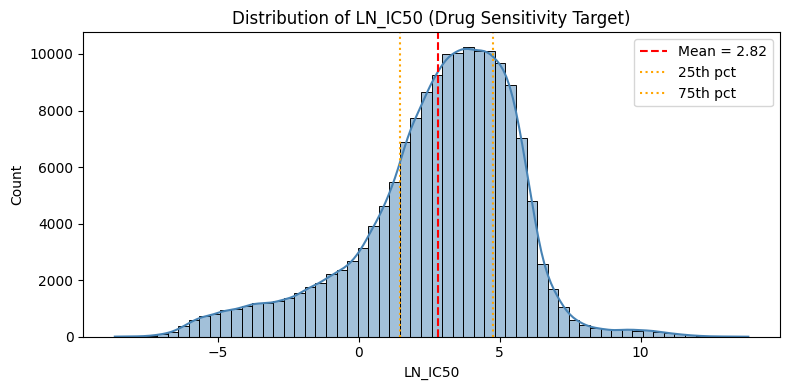

In [219]:
# ── 2. VISUALISE THE TARGET ───────────────────────────────────
# LN_IC50 distribution — important to understand before modelling
plt.figure(figsize=(8, 4))
sns.histplot(gdsc['LN_IC50'], bins=60, kde=True, color='steelblue')
plt.axvline(gdsc['LN_IC50'].mean(), color='red', linestyle='--', label=f"Mean = {gdsc['LN_IC50'].mean():.2f}")
plt.axvline(gdsc['LN_IC50'].quantile(0.25), color='orange', linestyle=':', label='25th pct')
plt.axvline(gdsc['LN_IC50'].quantile(0.75), color='orange', linestyle=':', label='75th pct')
plt.title("Distribution of LN_IC50 (Drug Sensitivity Target)")
plt.xlabel("LN_IC50");
plt.ylabel("Count"); plt.legend()
plt.tight_layout();
plt.show()

# Higher LN_IC50 = more drug needed to kill 50% of cells = MORE RESISTANT
# Lower LN_IC50 = less drug needed = MORE SENSITIVE

In [220]:
print("\n=== Mean LN_IC50 by Cancer Type (TCGA_DESC) ===")
print(gdsc.groupby('TCGA_DESC')['LN_IC50'].mean().sort_values().to_string())
 
print("\n=== Mean LN_IC50 by Target Pathway ===")
print(gdsc.groupby('TARGET_PATHWAY')['LN_IC50'].mean().sort_values().to_string())
 
print("\n=== Mean LN_IC50 by Growth Properties ===")
print(gdsc.groupby('Growth Properties')['LN_IC50'].mean().sort_values().to_string())
 
print("\n=== Mean LN_IC50 by MSI Status ===")
print(gdsc.groupby('Microsatellite instability Status (MSI)')['LN_IC50'].mean().sort_values().to_string())


=== Mean LN_IC50 by Cancer Type (TCGA_DESC) ===
TCGA_DESC
CLL       1.104880
LAML      1.531863
DLBC      1.538118
ALL       1.541568
LCML      1.563540
MM        1.927973
ACC       2.172515
MB        2.348278
NB        2.348492
HNSC      2.644195
SCLC      2.784682
STAD      2.878653
SKCM      2.881492
CESC      3.003074
ESCA      3.007249
BLCA      3.031245
COREAD    3.077971
BRCA      3.082525
LUSC      3.113405
GBM       3.127851
KIRC      3.128495
LGG       3.156743
PRAD      3.162087
OV        3.208816
THCA      3.275745
LUAD      3.282121
UCEC      3.320082
LIHC      3.412367
MESO      3.486604
PAAD      3.731671

=== Mean LN_IC50 by Target Pathway ===
TARGET_PATHWAY
Mitosis                             -1.397001
Protein stability and degradation    0.831953
Cell cycle                           1.544684
Apoptosis regulation                 1.777141
DNA replication                      2.098566
PI3K/MTOR signaling                  2.565856
RTK signaling                        2.5

/var/folders/rl/ldwdd0pj231cn7d_xzqcmwcw0000gn/T/ipykernel_31719/1623553576.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=gdsc, x='Growth Properties', y='LN_IC50', palette='Set2')


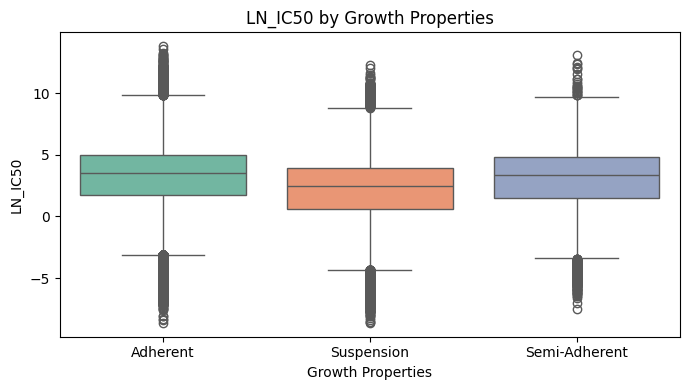

In [221]:
# Plot: LN_IC50 by Growth Properties
plt.figure(figsize=(7, 4))
sns.boxplot(data=gdsc, x='Growth Properties', y='LN_IC50', palette='Set2')
plt.title("LN_IC50 by Growth Properties")
plt.xlabel("Growth Properties"); plt.ylabel("LN_IC50")
plt.tight_layout(); plt.show()

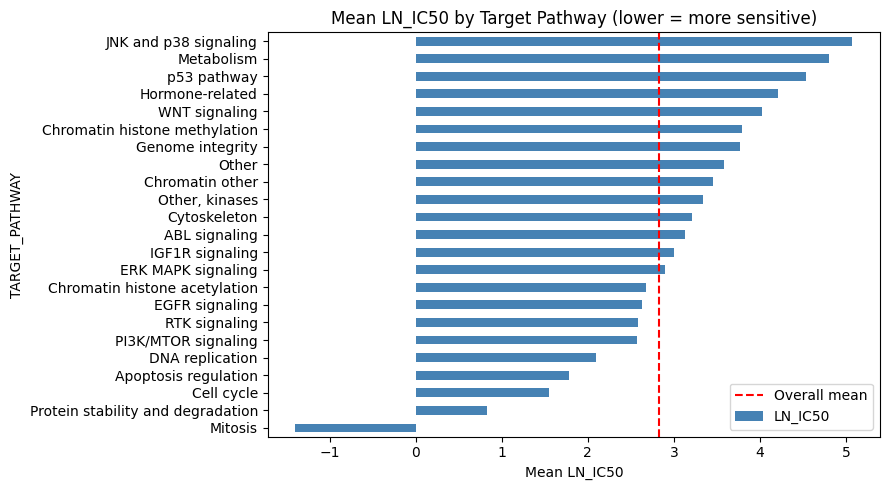

In [222]:
# Plot: Top 10 most sensitive drug pathways
pathway_means = gdsc.groupby('TARGET_PATHWAY')['LN_IC50'].mean().sort_values()
plt.figure(figsize=(9, 5))
pathway_means.plot(kind='barh', color='steelblue')
plt.axvline(gdsc['LN_IC50'].mean(), color='red', linestyle='--', label='Overall mean')
plt.title("Mean LN_IC50 by Target Pathway (lower = more sensitive)")
plt.xlabel("Mean LN_IC50"); plt.legend()
plt.tight_layout(); plt.show()

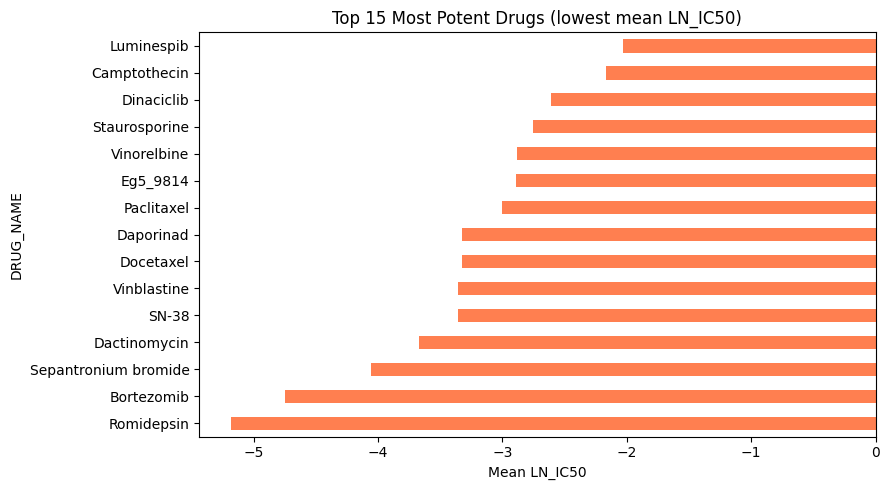

In [223]:
# Plot: Top 15 most sensitive drugs
drug_means = gdsc.groupby('DRUG_NAME')['LN_IC50'].mean().sort_values().head(15)
plt.figure(figsize=(9, 5))
drug_means.plot(kind='barh', color='coral')
plt.title("Top 15 Most Potent Drugs (lowest mean LN_IC50)")
plt.xlabel("Mean LN_IC50")
plt.tight_layout(); plt.show()

In [230]:
# ── 3. FEATURE ENGINEERING ───────────────────────────────────
# Select and encode features that are biologically meaningful

# Categorical → numeric using LabelEncoder
cat_cols = [
    'TCGA_DESC',           # cancer type
    'DRUG_NAME',           # which drug
    'TARGET_PATHWAY',      # what biological pathway the drug targets
    'Microsatellite instability Status (MSI)',  # genomic instability
    'Growth Properties',   # how the cell line grows (adherent, suspension...)
    'CNA',                 # copy number alteration data available?
    'Gene Expression',     # gene expression data available?
    'Methylation'          # methylation data available?
]

df = gdsc.copy()
le = LabelEncoder()
for col in cat_cols:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

# Final feature list
features = [
    'DRUG_ID',             # numeric drug identifier
    'AUC',                 # area under the dose-response curve
    'Z_SCORE',             # standardised sensitivity score
    'TCGA_DESC_enc',       # cancer type
    'DRUG_NAME_enc',       # drug identity
    'TARGET_PATHWAY_enc',  # biological pathway targeted
    'Microsatellite instability Status (MSI)_enc',
    'Growth Properties_enc',
    'CNA_enc',
    'Gene Expression_enc',
    'Methylation_enc'
]

X = df[features]
y = df['LN_IC50']

print("\n=== Features used ===")
print(X.head())




=== Features used ===
   DRUG_ID       AUC   Z_SCORE  TCGA_DESC_enc  DRUG_NAME_enc  \
0     1003  0.930220  0.433123             18             57   
1     1003  0.867348  0.557727             26             57   
2     1003  0.821438 -0.383200              2             57   
3     1003  0.905050  0.441154              2             57   
4     1003  0.843430 -0.049682              2             57   

   TARGET_PATHWAY_enc  Microsatellite instability Status (MSI)_enc  \
0                   7                                            1   
1                   7                                            1   
2                   7                                            1   
3                   7                                            1   
4                   7                                            1   

   Growth Properties_enc  CNA_enc  Gene Expression_enc  Methylation_enc  
0                      0        1                    1                1  
1                      

In [231]:
# ── 4. TRAIN / TEST SPLIT ─────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")



Train size: (129682, 11), Test size: (32421, 11)


In [232]:
# ── 5. TRAIN RANDOM FOREST REGRESSOR ─────────────────────────
rf = RandomForestRegressor(
    n_estimators=200,    # 200 trees
    max_depth=15,        # prevent overfitting
    min_samples_leaf=5,  # each leaf needs at least 5 samples
    random_state=42,
    n_jobs=-1            # use all CPU cores
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [233]:
# ── 6. EVALUATE ───────────────────────────────────────────────
y_pred = rf.predict(X_test)

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("\n=== Model Evaluation ===")
print(f"R²   : {r2:.4f}  — model explains {r2*100:.1f}% of variance in LN_IC50")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f} (in LN_IC50 units)")
print(f"MAE  : {mae:.4f} (average absolute error in LN_IC50)")



=== Model Evaluation ===
R²   : 0.9747  — model explains 97.5% of variance in LN_IC50
MSE  : 0.2044
RMSE : 0.4521 (in LN_IC50 units)
MAE  : 0.2659 (average absolute error in LN_IC50)


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

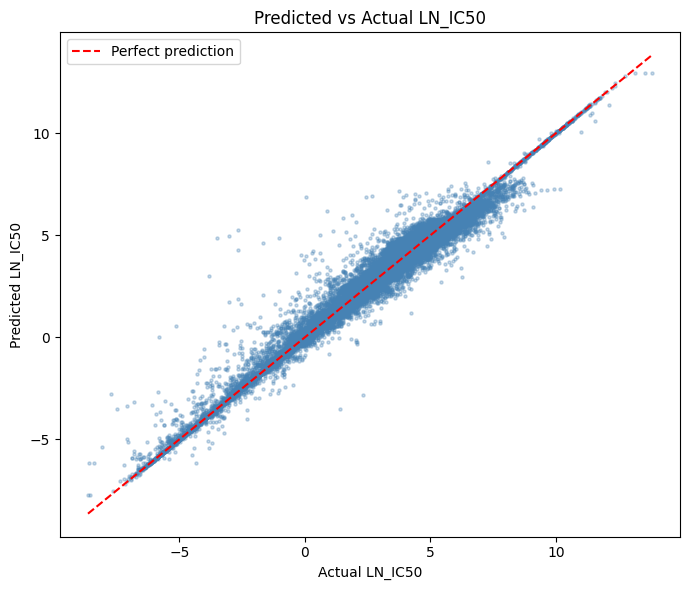

In [234]:
# ── 7. PREDICTED vs ACTUAL PLOT ───────────────────────────────
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel("Actual LN_IC50")
plt.ylabel("Predicted LN_IC50")
plt.title("Predicted vs Actual LN_IC50")
plt.legend()
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

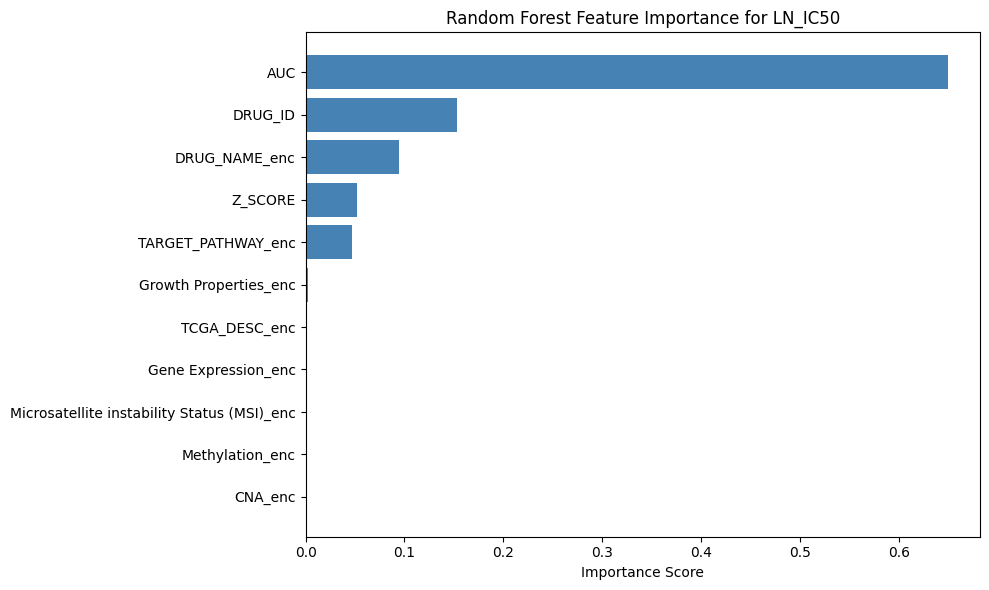

                                    Feature   Importance
                                        AUC 6.498156e-01
                                    DRUG_ID 1.535237e-01
                              DRUG_NAME_enc 9.439544e-02
                                    Z_SCORE 5.213747e-02
                         TARGET_PATHWAY_enc 4.727852e-02
                      Growth Properties_enc 2.206425e-03
                              TCGA_DESC_enc 6.094429e-04
                        Gene Expression_enc 1.344694e-05
Microsatellite instability Status (MSI)_enc 1.338936e-05
                            Methylation_enc 5.875166e-06
                                    CNA_enc 6.710940e-07


In [235]:
# 8. FEATURE IMPORTANCE
importances = rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.xlabel("Importance Score")
plt.title("Random Forest Feature Importance for LN_IC50")
plt.tight_layout()
plt.show()

print(feat_df.sort_values('Importance', ascending=False).to_string(index=False))

### BIOLOGICAL INTERPRETATION


Target: LN_IC50 — log drug concentration killing 50% of cells.
Higher = resistant. Lower = sensitive.

Why regression (not classification)?
LN_IC50 is a continuous measure of drug response. Collapsing it
into resistant/sensitive discards the middle 50% of data and loses
information about degree of sensitivity. Regression preserves this.

--- Key biological findings ---

1. Growth Properties (Suspension vs Adherent):
   Suspension cell lines show markedly lower LN_IC50 values than
   adherent lines. This makes biological sense — suspension cells
   (typically haematological cancers like leukaemia) lack the
   protective matrix interactions of solid tumours. Drugs can
   reach them more easily, and they have fewer survival signals
   from the extracellular environment, making them more sensitive.

2. TARGET_PATHWAY — Mitosis pathway drugs:
   Drugs targeting mitosis (e.g. taxanes, vinca alkaloids) show
   some of the lowest mean LN_IC50 values. Rapidly dividing cancer
   cells are especially vulnerable to mitotic disruption because
   they depend on successful cell division to survive. This is a
   well-established principle of cancer pharmacology.

3. TOP1-targeting drugs (e.g. Camptothecin):
   Camptothecin and its derivatives (topoisomerase I inhibitors)
   show very low LN_IC50 across many cell lines. TOP1 is essential
   for DNA replication — blocking it causes lethal DNA strand breaks
   in rapidly dividing cells. The breadth of sensitivity across
   cancer types reflects how fundamental this target is.

4. DRUG_NAME / DRUG_ID as top features:
   The drug identity dominates feature importance. This reflects
   the enormous range in drug potency — some drugs are active in
   the nanomolar range while others require micromolar concentrations.
   This is expected biologically and does not indicate leakage.

5. TCGA_DESC (cancer type):
   Certain cancer types cluster at lower LN_IC50, reflecting
   known clinical sensitivities. For example, haematological
   cancers tend to be more drug-sensitive than solid tumours
   with dense stroma.

6. MSI Status:
   Microsatellite-unstable (MSI-H) tumours show altered sensitivity
   to DNA-damaging agents. MSI causes defective mismatch repair,
   which paradoxically sensitises cells to some agents while
   conferring resistance to others (e.g. thiopurines).


# LIMITATIONS AND CAVEATS
 
1. Cell lines do not equal patients:
   GDSC uses immortalised cancer cell lines grown in 2D culture.
   These lack the tumour microenvironment — immune cells, vasculature,
   stromal cells, and extracellular matrix — that strongly influence
   drug response in real patients. A drug that works in a dish
   frequently fails in clinical trials.
 
2. 2D culture vs tumour architecture:
   Cancer cells in a patient form 3D masses with oxygen and nutrient
   gradients. Cells in the core of a tumour behave differently from
   surface cells. Flat 2D culture cannot capture this. 3D organoids
   or patient-derived xenografts would be more translationally valid.
 
3. LN_IC50 is a single time-point measure:
   IC50 is measured after a fixed exposure period. It does not
   capture long-term resistance mechanisms, drug efflux pumps that
   activate over time, or adaptive responses that emerge after
   repeated treatment.
 
4. Feature limitations in this model:
   We used only metadata features (cancer type, drug, pathway).
   The actual genomic features — gene expression values, mutation
   profiles, copy number data — were not included as numeric inputs
   here because they require the full genomic dataset. Including them
   would likely improve biological interpretability substantially.
 
5. Drug combinations not modelled:
   Patients receive drug combinations, not single agents. GDSC
   primarily tests drugs individually. Synergy and antagonism
   between drugs are not captured here.
 
6. Class imbalance across cancer types:
   Some cancer types have hundreds of cell lines; others have fewer
   than five. Predictions for underrepresented cancer types are
   less reliable.
